# Run all notebooks in the project

In [5]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_GG.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }


# ==========================================================
# EXAMPLES
# ==========================================================

# Example: access wrist data
# df_wrist_example = results["Data_GG.csv"]["wrist"]

# Example: compare datasets
# print(results["Data_droite.csv"]["wrist"].shape)
# print(results["Data_GG.csv"]["wrist"].shape)


===== FILE: Data_GG.csv =====
K-Push:
     time   force
0  0.000  0.5568
1  0.002  0.5443
2  0.004  0.5204
3  0.006  0.5267
4  0.008  0.4979

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000 -0.024048  0.608276  0.757263  0.236450
1  0.008 -0.023987  0.608316  0.757245  0.236484
2  0.016 -0.023865  0.608354  0.757192  0.236518
3  0.024 -0.023774  0.608357  0.757196  0.236488
4  0.032 -0.023713  0.608386  0.757225  0.236335

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.592041  0.160645  0.017517  0.789490
1  0.008 -0.592120  0.160436  0.017579  0.789483
2  0.016 -0.592270  0.160069  0.017701  0.789449
3  0.024 -0.592358  0.159946  0.017762  0.789414
4  0.032 -0.592305  0.160162  0.017670  0.789394

Baseline wrist: [-0.049, 0.636, 0.742, 0.207]
Baseline shoulder: [-0.593, 0.166, 0.018, 0.787]

Shapes: (31630, 2) (7905, 5) (7905, 5)


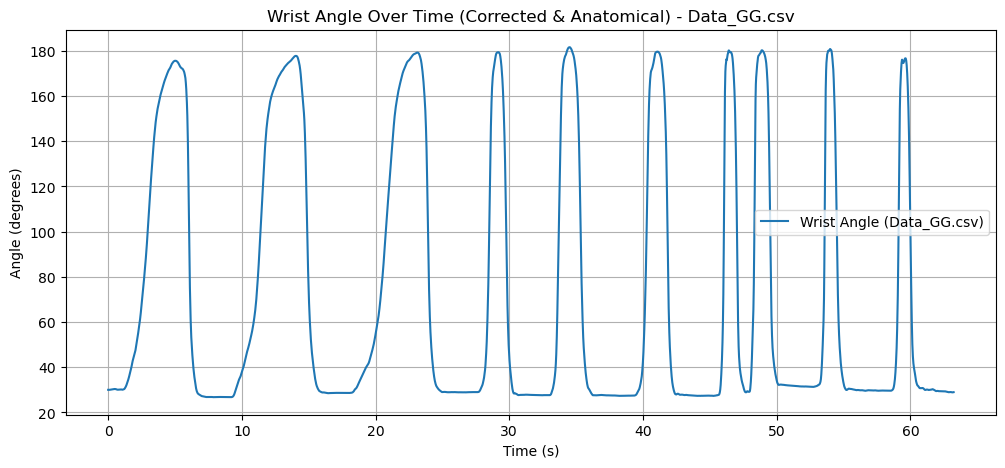

===== FILE: Data_GG.csv =====
Min angle: 26.721407057727433
Max angle: 181.5875169468768


In [17]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_GG.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_droite.csv": 30,
    "Data_GG.csv": 30
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

First 5 rows with filtered angle:
     time      angle  angle_filt
0  0.000  30.000000   29.999890
1  0.008  29.993578   29.994153
2  0.016  29.988104   29.988808
3  0.024  29.987324   29.984173
4  0.032  29.981599   29.980514


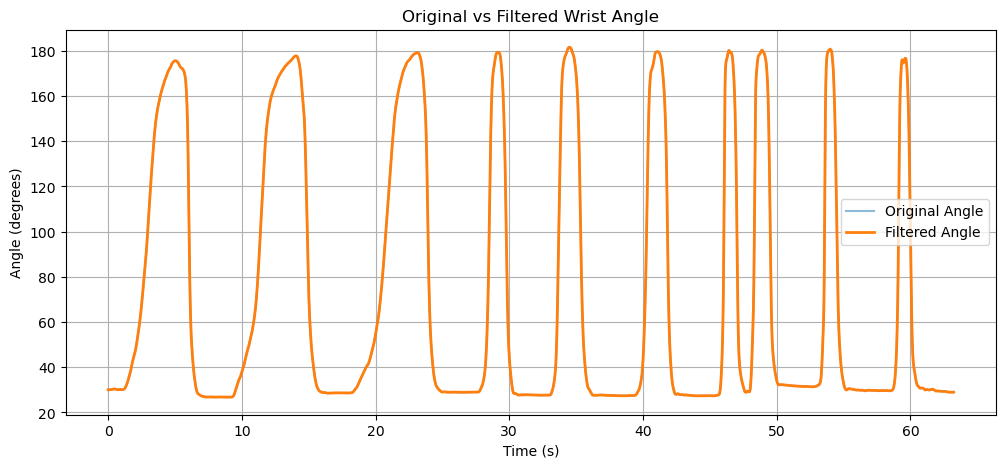

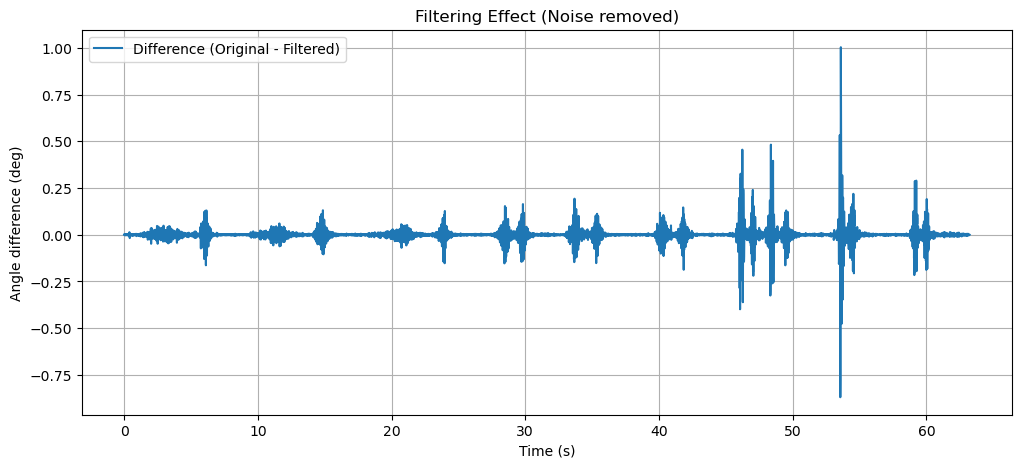

In [18]:
## STEP 3 : FILTER the data  + Chek results with plots 

from scipy.signal import butter, filtfilt

def lowpass_filter(signal, fs, cutoff=10, order=4):
    """
    Apply a Butterworth low-pass filter.

    Parameters:
        signal : array-like
        fs : sampling frequency (Hz)
        cutoff : cutoff frequency (Hz)
        order : filter order

    Returns:
        filtered_signal
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

# ---------- APPLY FILTER TO ANGLE ----------
fs = 125  # sampling frequency

df_wrist_angles["angle_filt"] = lowpass_filter(
    df_wrist_angles["angle"],
    fs=fs,
    cutoff=10
)
# ---------- CHECK ----------
print("First 5 rows with filtered angle:\n", df_wrist_angles.head())
plt.figure(figsize=(12,5))
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle"],
    label="Original Angle",
    alpha=0.5
)
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle_filt"],
    label="Filtered Angle",
    linewidth=2
)
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Original vs Filtered Wrist Angle")
plt.legend()
plt.grid(True)
plt.show()   

# Difference signal
df_wrist_angles["diff"] = df_wrist_angles["angle"] - df_wrist_angles["angle_filt"]

plt.figure(figsize=(12,5))

plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["diff"],
    label="Difference (Original - Filtered)"
)

plt.xlabel("Time (s)")
plt.ylabel("Angle difference (deg)")
plt.title("Filtering Effect (Noise removed)")
plt.legend()
plt.grid(True)

plt.show()

Extension peaks (max): [1755 2890 3647 4314 5137 5803 6112 6749 7453]
Extension values: [177.75671611 179.20859291 179.39245948 181.58940503 179.65596377
 180.15945653 180.2572645  180.76144024 176.70523512]
Flexion peaks (min): [ 920 1140 2060 3837 4061 4562 4811 5445 5660]
Flexion values: [26.80292357 26.71978837 28.49757873 27.66348187 27.60737161 27.56069195
 27.31436486 27.50991102 27.30888692]
Number of extension peaks: 9
Number of flexion peaks: 9


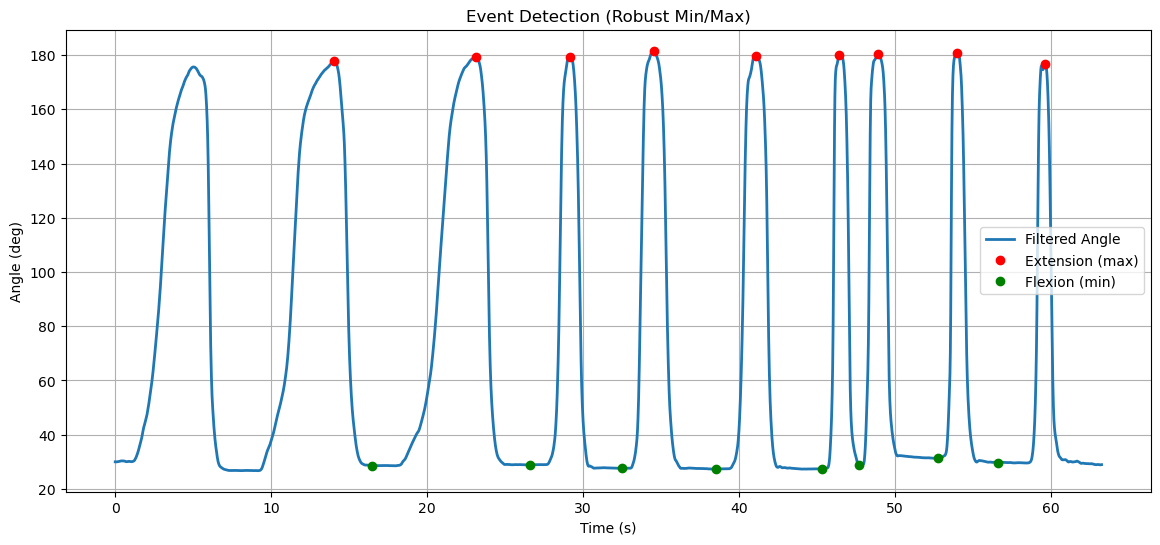

In [19]:
# STEP 4 : EVENT DETECTION from the PEAK +  CHECK RESULTS WITH PLOTS

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---------- STEP 5: EVENT DETECTION FROM FILTERED ANGLE ----------

# Use filtered angle
signal = df_wrist_angles["angle_filt"].values
time = df_wrist_angles["time"].values

# ---------- 1. DETECT EXTENSION (MAXIMA) ----------
peaks_extension, _ = find_peaks(
    signal,
    distance=200
)

# ---------- 2. DETECT FLEXION (MINIMA) ----------
peaks_flexion_all, _ = find_peaks(
    -signal,
    distance=200
)

# Get values
flexion_values = signal[peaks_flexion_all]

# Sort (lowest = strongest flexion)
sorted_indices = np.argsort(flexion_values)

# Keep 9 deepest minima
peaks_flexion = np.sort(peaks_flexion_all[sorted_indices[:9]])

# ---------- OPTIONAL FIX ----------
if signal[0] > signal[1]:
    peaks_extension = np.insert(peaks_extension, 0, 0)

# keep the 9 highest maxima
ext_values = signal[peaks_extension]
top_idx = np.argsort(ext_values)[-9:]
peaks_extension = np.sort(peaks_extension[top_idx])

# ---------- DEBUG ----------
print("Extension peaks (max):", peaks_extension)
print("Extension values:", signal[peaks_extension])

print("Flexion peaks (min):", peaks_flexion)
print("Flexion values:", signal[peaks_flexion])

print("Number of extension peaks:", len(peaks_extension))
print("Number of flexion peaks:", len(peaks_flexion))

# ---------- FORCE 1 MINIMUM BETWEEN EACH MAX ----------
peaks_flexion_fixed = []

for i in range(len(peaks_extension) - 1):
    start = peaks_extension[i]
    end = peaks_extension[i+1]

    # segment between two maxima
    segment = signal[start:end]

    if len(segment) == 0:
        continue

    # find minimum in this segment
    local_min_idx = np.argmin(segment)

    # convert to global index
    peaks_flexion_fixed.append(start + local_min_idx)

peaks_flexion_fixed = np.array(peaks_flexion_fixed)


plt.figure(figsize=(14,6))

plt.plot(time, signal, label="Filtered Angle", linewidth=2)

# Max (extension)
plt.plot(time[peaks_extension], signal[peaks_extension],
         "ro", label="Extension (max)")

# Min (flexion)
plt.plot(time[peaks_flexion_fixed], signal[peaks_flexion_fixed],
         "go", label="Flexion (min)")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Detection (Robust Min/Max)")
plt.legend()
plt.grid(True)

plt.show()

In [20]:


# Step 6 : Associate events to force

# Convert event indices to time
event_times = time[peaks_extension]

# Find corresponding force values
force_values = []

for t in event_times:
    idx_force = (df_push["time"] - t).abs().idxmin()
    force_values.append(df_push["force"].iloc[idx_force])

df_events = pd.DataFrame({
    "time": event_times,
    "angle": signal[peaks_extension],
    "force": force_values
})

print(df_events.head())

      time       angle   force
0  14.0401  177.756716  0.2239
1  23.1201  179.208593  0.0000
2  29.1761  179.392459  0.0000
3  34.5121  181.589405  0.0000
4  41.0961  179.655964  0.0000


Slow Events:
       time       angle   force
0  14.0401  177.756716  0.2239
1  23.1201  179.208593  0.0000
2  29.1761  179.392459  0.0000

Medium Events:
       time       angle   force
0  34.5121  181.589405  0.0000
1  41.0961  179.655964  0.0000
2  46.4241  180.159457  0.4204

Fast Events:
       time       angle   force
0  48.8961  180.257265  0.3906
1  53.9921  180.761440  0.3441
2  59.6241  176.705235  0.0000


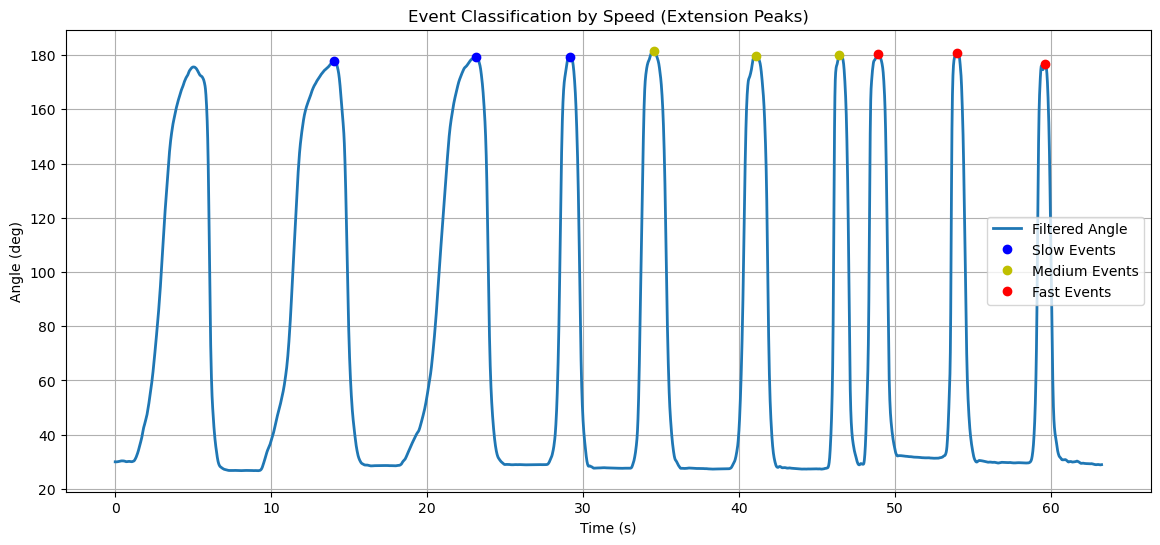

In [21]:
# ==========================================================
# STEP 7: CLASSIFY EVENTS INTO SPEED CATEGORIES
# ==========================================================

import pandas as pd

# ---------- PARAMETERS ----------
# Assume we have 9 extension peaks (already detected)
n_events_per_category = 3  # 3 slow, 3 medium, 3 fast

# Sort peaks by time to respect chronological order
sorted_extension_peaks = np.sort(peaks_extension)

# Split into 3 categories: slow, medium, fast
slow_peaks = sorted_extension_peaks[:n_events_per_category]
medium_peaks = sorted_extension_peaks[n_events_per_category:2*n_events_per_category]
fast_peaks = sorted_extension_peaks[2*n_events_per_category:3*n_events_per_category]

# ---------- ASSOCIATE ANGLE AND FORCE ----------
def get_event_data(peaks, signal, df_push, time_array):
    """
    Get angle and corresponding force for each peak.
    
    peaks : array of peak indices
    signal : filtered angle signal
    df_push : dataframe with force data (time + force)
    time_array : array of time values
    """
    event_times = time_array[peaks]
    force_values = []
    for t in event_times:
        idx_force = (df_push["time"] - t).abs().idxmin()  # find nearest time in force
        force_values.append(df_push["force"].iloc[idx_force])
    
    df_events = pd.DataFrame({
        "time": event_times,
        "angle": signal[peaks],
        "force": force_values
    })
    
    return df_events

# ---------- CREATE DATAFRAMES FOR EACH CATEGORY ----------
df_slow = get_event_data(slow_peaks, signal, df_push, time)
df_medium = get_event_data(medium_peaks, signal, df_push, time)
df_fast = get_event_data(fast_peaks, signal, df_push, time)

# ---------- PRINT RESULTS ----------
print("Slow Events:\n", df_slow)
print("\nMedium Events:\n", df_medium)
print("\nFast Events:\n", df_fast)

# ---------- OPTIONAL: PLOT EVENTS WITH COLORS ----------
plt.figure(figsize=(14,6))
plt.plot(time, signal, label="Filtered Angle", linewidth=2)
plt.plot(time[slow_peaks], signal[slow_peaks], "bo", label="Slow Events")
plt.plot(time[medium_peaks], signal[medium_peaks], "yo", label="Medium Events")
plt.plot(time[fast_peaks], signal[fast_peaks], "ro", label="Fast Events")
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Classification by Speed (Extension Peaks)")
plt.legend()
plt.grid(True)
plt.show()

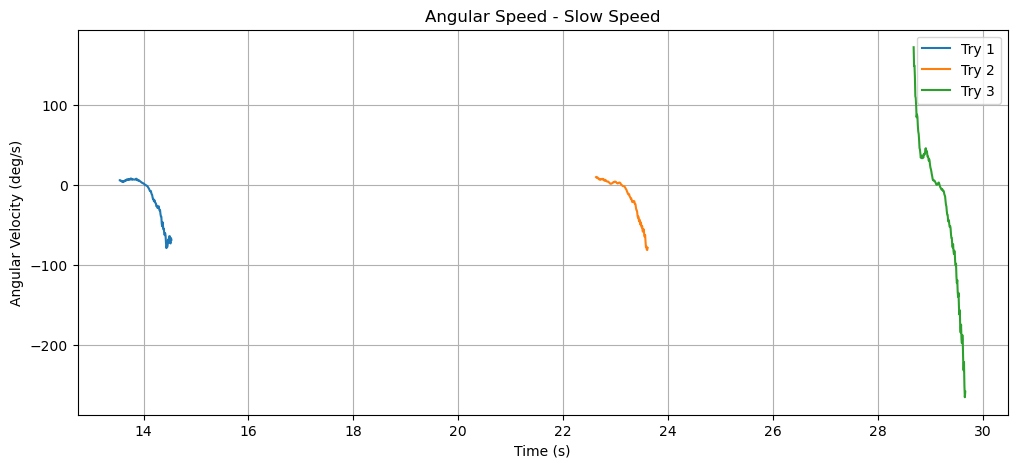

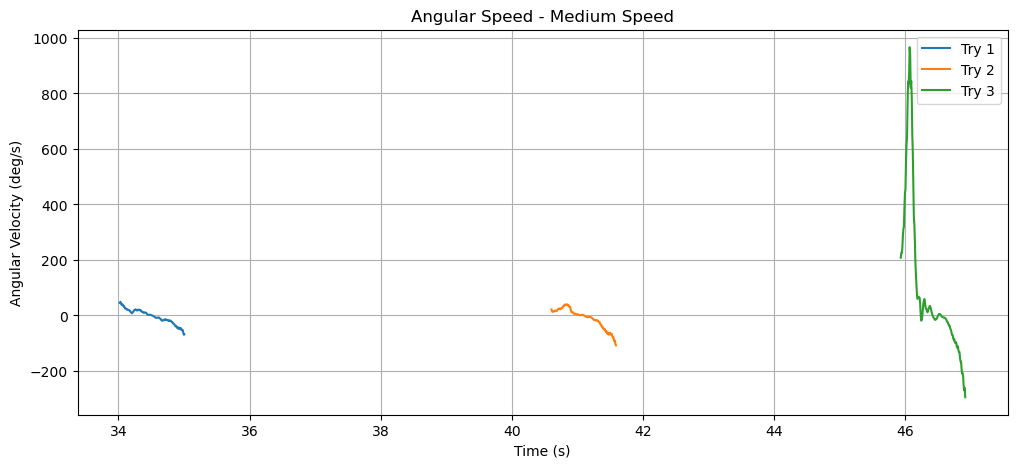

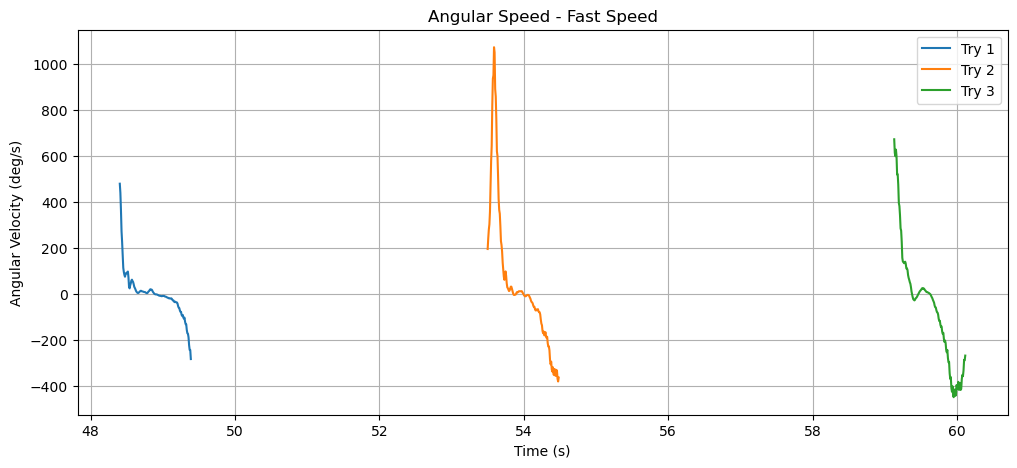

In [22]:
# ==========================================================
# STEP 8: COMPUTE ANGULAR VELOCITY AND PLOT PER CATEGORY
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------- FUNCTION TO COMPUTE ANGULAR VELOCITY ----------
def compute_angular_velocity(df_angles):
    """
    Compute angular velocity (deg/s) from a dataframe with time and angle.

    df_angles: dataframe with columns "time" and "angle"

    Returns:
        time_mid: array of times for velocity points
        vel: array of angular velocities
    """
    time = df_angles["time"].values
    angle = df_angles["angle"].values

    # Compute derivative (angular velocity) using np.diff
    vel = np.diff(angle) / np.diff(time)

    # Midpoint times for derivative points
    time_mid = time[:-1] + np.diff(time)/2

    return time_mid, vel

# ---------- FUNCTION TO EXTRACT ANGLE SEGMENTS AROUND EVENTS ----------
def extract_event_segments(peaks, df_angles, window=0.5):
    """
    Extract small segments of the angle signal around each peak.
    
    peaks: array of indices of extension peaks
    df_angles: full angle dataframe
    window: time before/after peak to include (s)
    """
    segments = []
    for peak in peaks:
        t_peak = df_angles["time"].iloc[peak]
        # Select segment ±window around peak
        seg = df_angles[(df_angles["time"] >= t_peak - window) &
                        (df_angles["time"] <= t_peak + window)].copy()
        segments.append(seg)
    return segments

# ---------- PLOT FUNCTION ----------
def plot_angular_velocity_category(df_angles, peaks, category_name):
    """
    Plot angular velocity for each of the 3 events in a category.
    """
    segments = extract_event_segments(peaks, df_angles, window=0.5)

    plt.figure(figsize=(12,5))

    for i, seg in enumerate(segments):
        time_mid, vel = compute_angular_velocity(seg)
        plt.plot(time_mid, vel, label=f"Try {i+1}")

    plt.xlabel("Time (s)")
    plt.ylabel("Angular Velocity (deg/s)")
    plt.title(f"Angular Speed - {category_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


# ---------- APPLY TO EACH CATEGORY ----------

# Slow events
plot_angular_velocity_category(df_wrist_angles, slow_peaks, "Slow Speed")

# Medium events
plot_angular_velocity_category(df_wrist_angles, medium_peaks, "Medium Speed")

# Fast events
plot_angular_velocity_category(df_wrist_angles, fast_peaks, "Fast Speed")

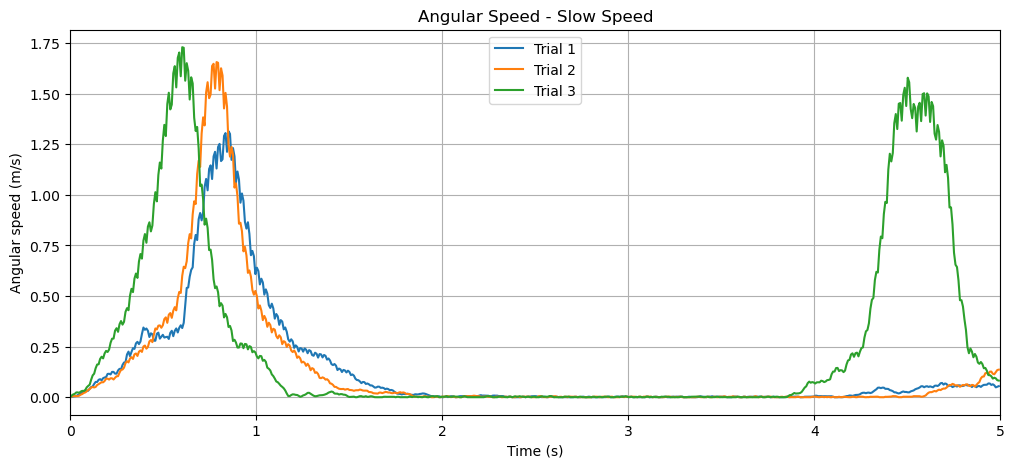

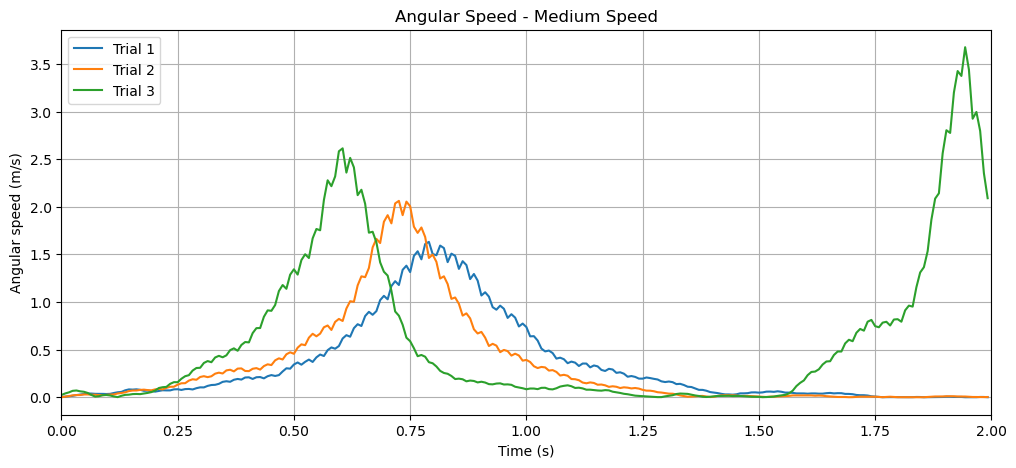

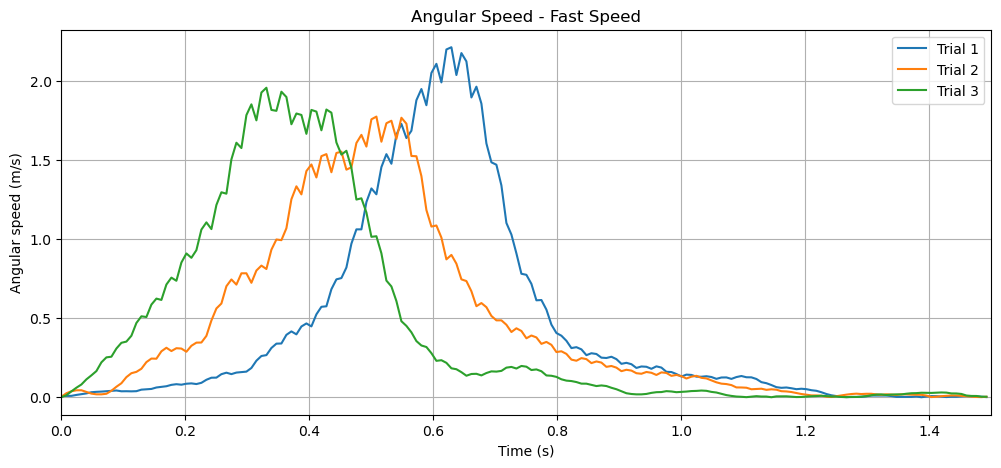

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
r = 0.25  # radius from joint center to wrist (m)
window_dict = {"Slow": 5.0, "Medium": 2.0, "Fast": 1.5}  # x-axis windows

# ---------- FUNCTION: ANGULAR VELOCITY ----------
def compute_angular_velocity_m_per_s(df_angles, r):
    """
    Convert angles (deg) to linear speed (m/s)
    using absolute value to avoid negative speeds.
    """
    time = df_angles["time"].values
    angle = df_angles["angle"].values
    angle_rad = np.radians(angle)
    vel_rad_s = np.diff(angle_rad) / np.diff(time)
    vel_m_s = np.abs(vel_rad_s) * r  # <-- take absolute value
    time_mid = time[:-1] + np.diff(time)/2
    return time_mid, vel_m_s

# ---------- FUNCTION: EXTRACT SYNCHRONIZED SEGMENTS ----------
def extract_synchronized_segments(peaks, df_angles, total_window):
    """
    Extract a segment of fixed number of points after each peak.
    Ensures segments are not empty.
    """
    segments = []
    dt = np.mean(np.diff(df_angles["time"]))  # sampling interval
    n_points = int(total_window / dt)         # number of points to include

    for peak in peaks:
        start_idx = peak
        end_idx = min(peak + n_points, len(df_angles))
        seg = df_angles.iloc[start_idx:end_idx].copy()
        seg["time_sync"] = np.linspace(0, total_window, len(seg))  # rescale x-axis to window
        segments.append(seg)
    return segments

# ---------- FUNCTION: PLOT SYNCHRONIZED VELOCITY ----------
def plot_synchronized_velocity(df_angles, peaks, category_name, window, r):
    """
    Plot multiple trials of the same speed, synchronized in time.
    """
    segments = extract_synchronized_segments(peaks, df_angles, window)

    plt.figure(figsize=(12,5))

    for i, seg in enumerate(segments):
        if len(seg) < 2:
            continue  # skip empty segments
        time_mid, vel = compute_angular_velocity_m_per_s(seg, r)
        plt.plot(seg["time_sync"][:-1], vel, label=f"Trial {i+1}")

    plt.xlabel("Time (s)")
    plt.ylabel("Angular speed (m/s)")
    plt.title(f"Angular Speed - {category_name}")
    plt.grid(True)
    plt.xlim(0, window)
    plt.legend()
    plt.show()

# ---------- EXAMPLES ----------
plot_synchronized_velocity(df_wrist_angles, slow_peaks, "Slow Speed", window_dict["Slow"], r)
plot_synchronized_velocity(df_wrist_angles, medium_peaks, "Medium Speed", window_dict["Medium"], r)
plot_synchronized_velocity(df_wrist_angles, fast_peaks, "Fast Speed", window_dict["Fast"], r)

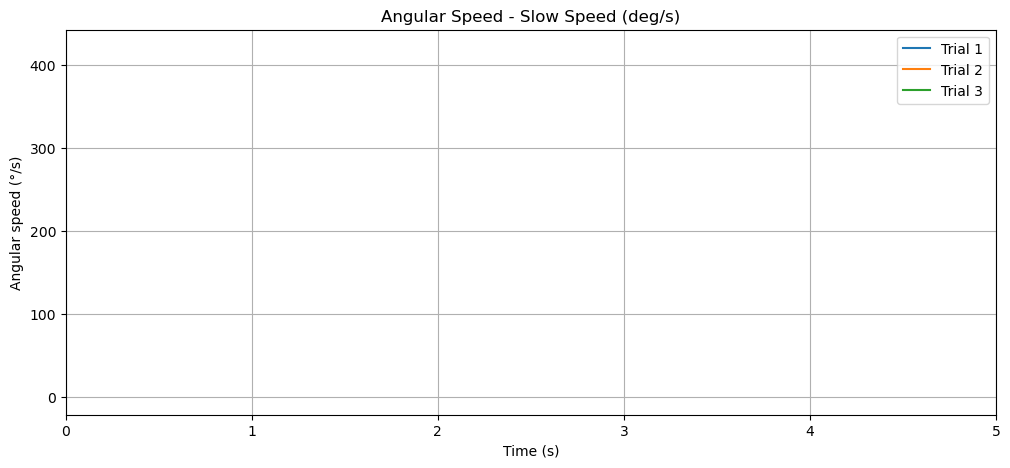

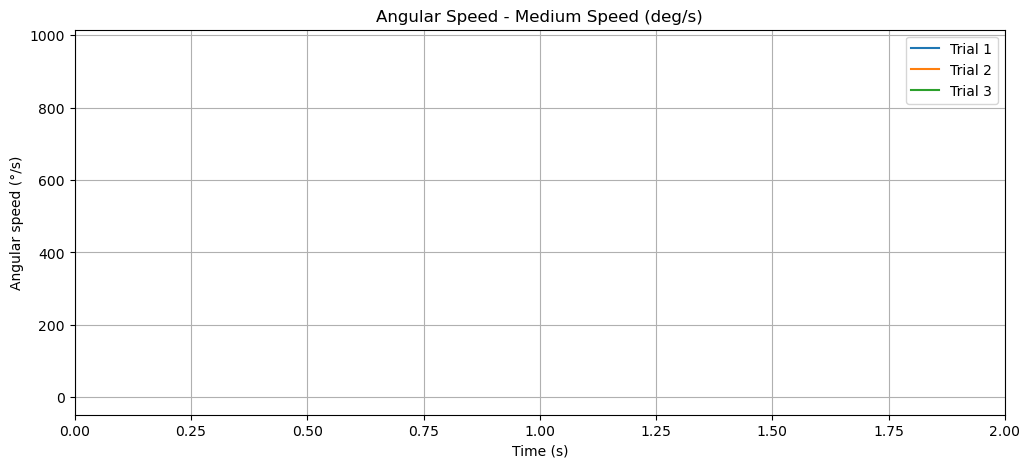

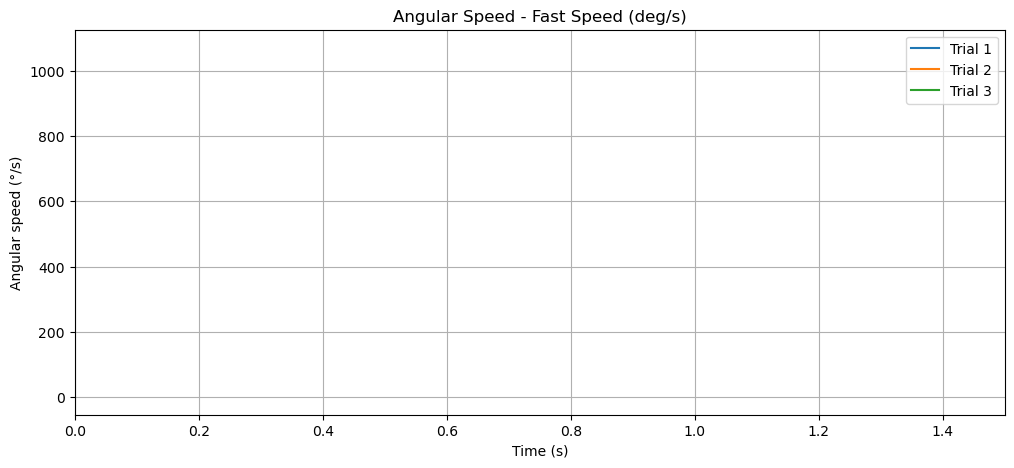

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- FUNCTION TO COMPUTE ANGULAR VELOCITY IN deg/s ----------
def compute_angular_velocity_deg_per_s(df_angles):
    """
    Compute angular speed in degrees per second from angle data.
    Returns midpoint times and absolute angular velocity.
    """
    if len(df_angles) < 2:
        return np.array([]), np.array([])  # Not enough points

    time = df_angles["time"].values
    angle = df_angles["angle"].values

    vel_deg_s = np.diff(angle) / np.diff(time)  # derivative (deg/s)
    vel_deg_s = np.abs(vel_deg_s)              # keep positive
    time_mid = time[:-1] + np.diff(time)/2     # midpoint times

    return time_mid, vel_deg_s

# ---------- FUNCTION TO EXTRACT SYNCHRONIZED SEGMENTS ----------
def extract_synchronized_segments(peaks, df_angles, total_window):
    """
    Extract segments around each peak and rescale time to start at 0.
    total_window: duration in seconds for the plot
    """
    segments = []
    for peak in peaks:
        t_peak = df_angles["time"].iloc[peak]
        seg = df_angles[(df_angles["time"] >= t_peak - total_window/2) &
                        (df_angles["time"] <= t_peak + total_window/2)].copy()
        if len(seg) < 2:
            continue  # skip segments too short to differentiate
        seg["time_sync"] = seg["time"] - seg["time"].iloc[0]
        segments.append(seg)
    return segments

# ---------- FUNCTION TO PLOT CATEGORY ----------
def plot_synchronized_velocity_deg(df_angles, peaks, category_name, window):
    """
    Plot 3 trials of same speed (deg/s) synchronized on x-axis.
    """
    segments = extract_synchronized_segments(peaks, df_angles, window)

    if len(segments) == 0:
        print(f"No valid segments found for {category_name}")
        return

    plt.figure(figsize=(12,5))

    for i, seg in enumerate(segments[:3]):  # only first 3 trials
        time_mid, vel = compute_angular_velocity_deg_per_s(seg)
        if len(vel) == 0:
            continue
        plt.plot(time_mid, vel, label=f"Trial {i+1}")

    plt.xlabel("Time (s)")
    plt.ylabel("Angular speed (°/s)")
    plt.title(f"Angular Speed - {category_name} (deg/s)")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, window)
    plt.show()

# ---------- PARAMETERS ----------
window_dict = {
    "Slow": 5.0,
    "Medium": 2.0,
    "Fast": 1.5
}

# ---------- PLOT ALL CATEGORIES ----------
plot_synchronized_velocity_deg(df_wrist_angles, slow_peaks, "Slow Speed", window_dict["Slow"])
plot_synchronized_velocity_deg(df_wrist_angles, medium_peaks, "Medium Speed", window_dict["Medium"])
plot_synchronized_velocity_deg(df_wrist_angles, fast_peaks, "Fast Speed", window_dict["Fast"])

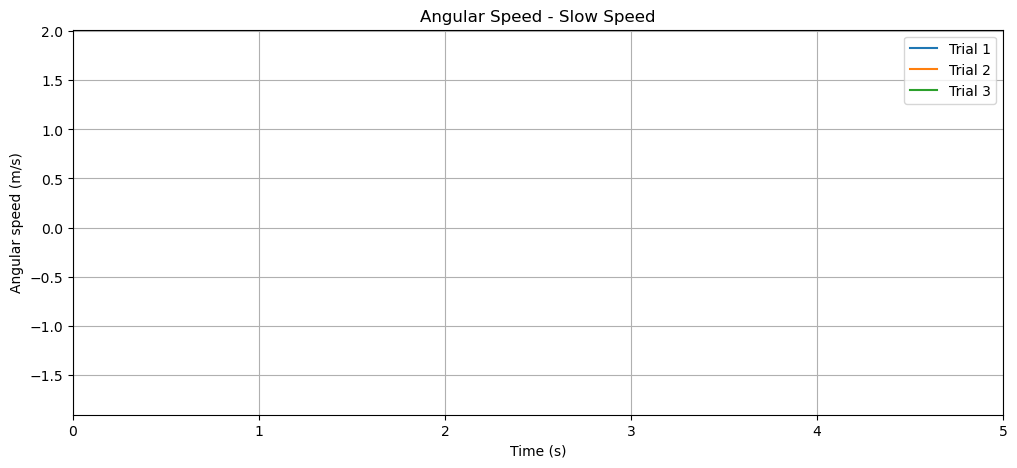

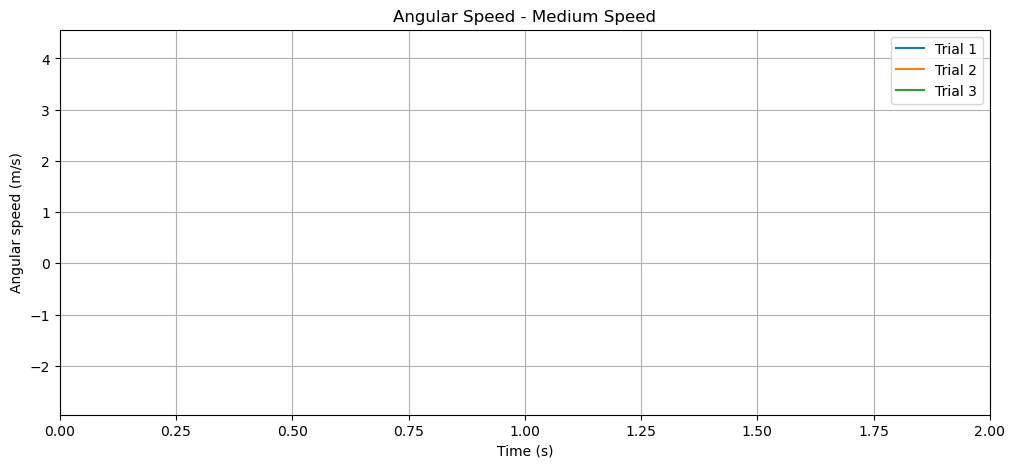

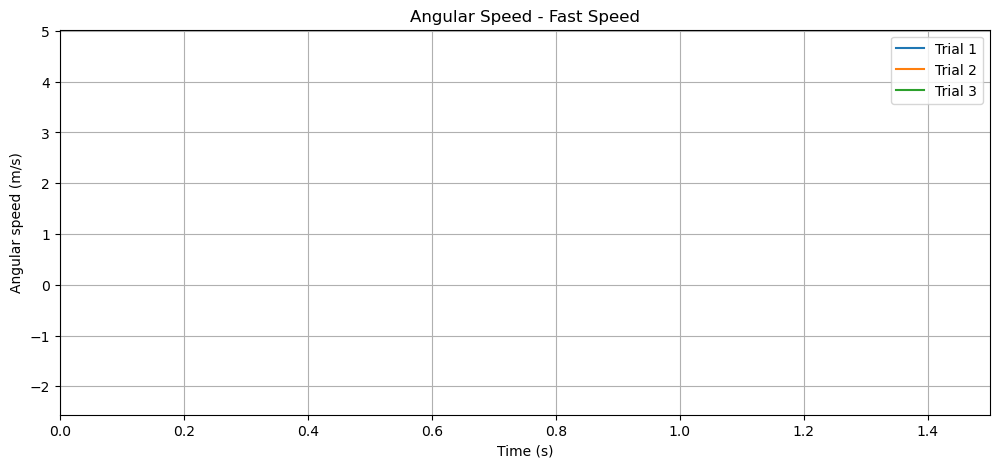

In [25]:
def extract_synchronized_segments(peaks, df_angles, total_window):
    """
    Extract segments for each peak and rescale time to start at 0.
    total_window: duration of x-axis (s) for the plot
    """
    segments = []
    dt = np.mean(np.diff(df_angles["time"]))  # sampling interval

    n_points = int(total_window / dt)  # number of points to include

    for peak in peaks:
        start_idx = peak
        end_idx = min(peak + n_points, len(df_angles))  # make sure we don't go past the array
        seg = df_angles.iloc[start_idx:end_idx].copy()
        # shift time to start at 0
        seg["time_sync"] = seg["time"] - seg["time"].iloc[0]
        segments.append(seg)
    return segments

# ==========================================================
# STEP 9: SYNCHRONIZED ANGULAR VELOCITY PLOTS PER CATEGORY
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETER ----------
# radius of rotation (m), for converting deg/s → m/s
r = 0.25  # example: 25 cm from joint center to wrist

# window length (s) for each category
window_dict = {
    "Slow": 5.0,
    "Medium": 2.0,
    "Fast": 1.5
}

# ---------- FUNCTION TO COMPUTE ANGULAR VELOCITY IN m/s ----------
def compute_angular_velocity_m_per_s(df_angles, r):
    """
    Compute linear velocity (m/s) from angle data in degrees.
    """
    time = df_angles["time"].values
    angle = df_angles["angle"].values

    # Convert deg to rad
    angle_rad = np.radians(angle)

    # Compute derivative
    vel_rad_s = np.diff(angle_rad) / np.diff(time)

    # Convert to linear velocity (v = r * omega)
    vel_m_s = vel_rad_s * r

    # Midpoint times
    time_mid = time[:-1] + np.diff(time)/2

    return time_mid, vel_m_s

# ---------- FUNCTION TO EXTRACT SYNCHRONIZED SEGMENTS ----------
def extract_synchronized_segments(peaks, df_angles, total_window):
    """
    Extract segments for each peak and rescale time to start at 0.
    total_window: duration of x-axis (s) for the plot
    """
    segments = []
    for peak in peaks:
        t_peak = df_angles["time"].iloc[peak]
        seg = df_angles[(df_angles["time"] >= t_peak - total_window/2) &
                        (df_angles["time"] <= t_peak + total_window/2)].copy()
        # shift time to start at 0
        seg["time_sync"] = seg["time"] - seg["time"].iloc[0]
        segments.append(seg)
    return segments

# ---------- FUNCTION TO PLOT CATEGORY ----------
def plot_synchronized_velocity(df_angles, peaks, category_name, window, r):
    """
    Plot 3 trials of same speed, synchronized to 0 on x-axis.
    """
    segments = extract_synchronized_segments(peaks, df_angles, window)

    plt.figure(figsize=(12,5))

    for i, seg in enumerate(segments):
        time_mid, vel = compute_angular_velocity_m_per_s(seg, r)
        plt.plot(time_mid, vel, label=f"Trial {i+1}")

    plt.xlabel("Time (s)")
    plt.ylabel("Angular speed (m/s)")
    plt.title(f"Angular Speed - {category_name}")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, window)

    plt.show()

# ---------- PLOT ALL CATEGORIES ----------
plot_synchronized_velocity(df_wrist_angles, slow_peaks, "Slow Speed", window_dict["Slow"], r)
plot_synchronized_velocity(df_wrist_angles, medium_peaks, "Medium Speed", window_dict["Medium"], r)
plot_synchronized_velocity(df_wrist_angles, fast_peaks, "Fast Speed", window_dict["Fast"], r)

In [26]:
def extract_synchronized_segments(peaks, df_angles, total_window):
    """
    Extract segments for each peak and rescale time to start at 0.
    total_window: duration of x-axis (s) for the plot
    """
    segments = []
    dt = np.mean(np.diff(df_angles["time"]))  # sampling interval

    n_points = int(total_window / dt)  # number of points to include

    for peak in peaks:
        start_idx = peak
        end_idx = min(peak + n_points, len(df_angles))  # make sure we don't go past the array
        seg = df_angles.iloc[start_idx:end_idx].copy()
        # shift time to start at 0
        seg["time_sync"] = seg["time"] - seg["time"].iloc[0]
        segments.append(seg)
    return segments

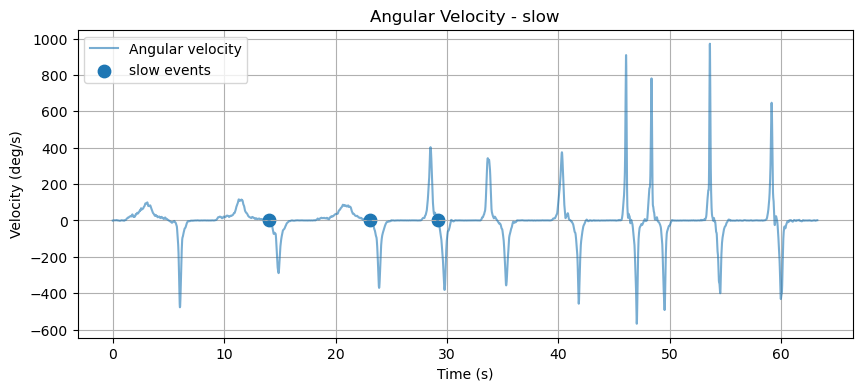

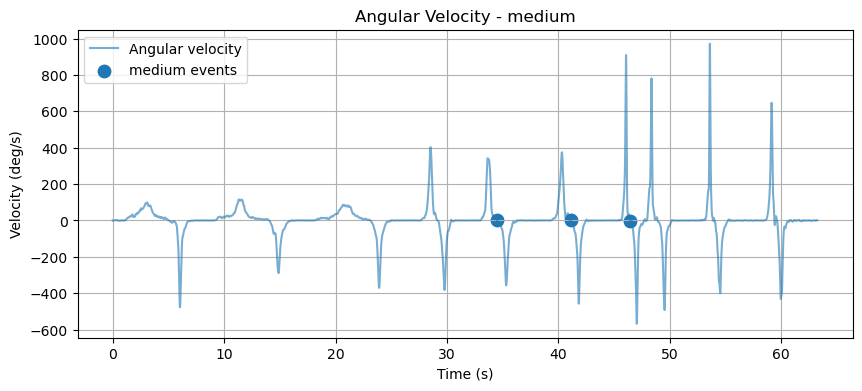

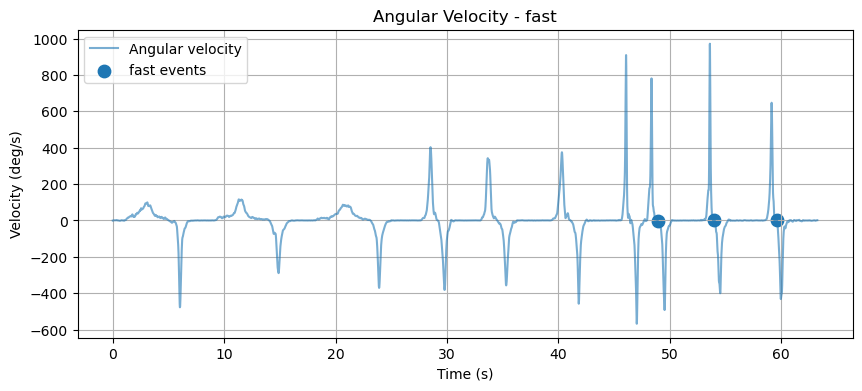

In [27]:
# STEP 7 : plot angular speed  vs time for each event (slow, mid and fast)

angular_velocity = np.gradient(signal, time)

df_wrist_angles["angular_velocity"] = angular_velocity

# Keep only 9 maxima
peaks_extension = peaks_extension[:9]

# Create labels
speed_labels = ["slow"]*3 + ["medium"]*3 + ["fast"]*3

df_events = pd.DataFrame({
    "index": peaks_extension,
    "time": time[peaks_extension],
    "angle": signal[peaks_extension],
    "speed": speed_labels
})

for speed in ["slow", "medium", "fast"]:
    subset = df_events[df_events["speed"] == speed]

    plt.figure(figsize=(10,4))
    
    plt.plot(time, angular_velocity, label="Angular velocity", alpha=0.6)

    plt.scatter(
        subset["time"],
        angular_velocity[subset["index"]],
        label=f"{speed} events",
        s=80
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (deg/s)")
    plt.title(f"Angular Velocity - {speed}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [28]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_droite.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }


# ==========================================================
# EXAMPLES
# ==========================================================

# Example: access wrist data
# df_wrist_example = results["Data_GG.csv"]["wrist"]

# Example: compare datasets
# print(results["Data_droite.csv"]["wrist"].shape)
# print(results["Data_GG.csv"]["wrist"].shape)


===== FILE: Data_droite.csv =====
K-Push:
     time   force
0  0.000  0.3391
1  0.002  0.3241
2  0.004  0.3271
3  0.006  0.3260
4  0.008  0.2902

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.180603 -0.564087 -0.615723  0.519531
1  0.008  0.180578 -0.564136 -0.615774  0.519518
2  0.016  0.180548 -0.564166 -0.615834  0.519426
3  0.024  0.180547 -0.564194 -0.615922  0.519301
4  0.032  0.180516 -0.564223 -0.616013  0.519178

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.662598  0.119934 -0.083679  0.734497
1  0.008 -0.662614  0.119937 -0.083651  0.734515
2  0.016 -0.662615  0.119937 -0.083620  0.734516
3  0.024 -0.662615  0.119937 -0.083590  0.734517
4  0.032 -0.662616  0.119937 -0.083559  0.734518

Baseline wrist: [0.147, -0.607, -0.628, 0.465]
Baseline shoulder: [-0.659, 0.119, -0.083, 0.738]

Shapes: (20840, 2) (5205, 5) (5205, 5)


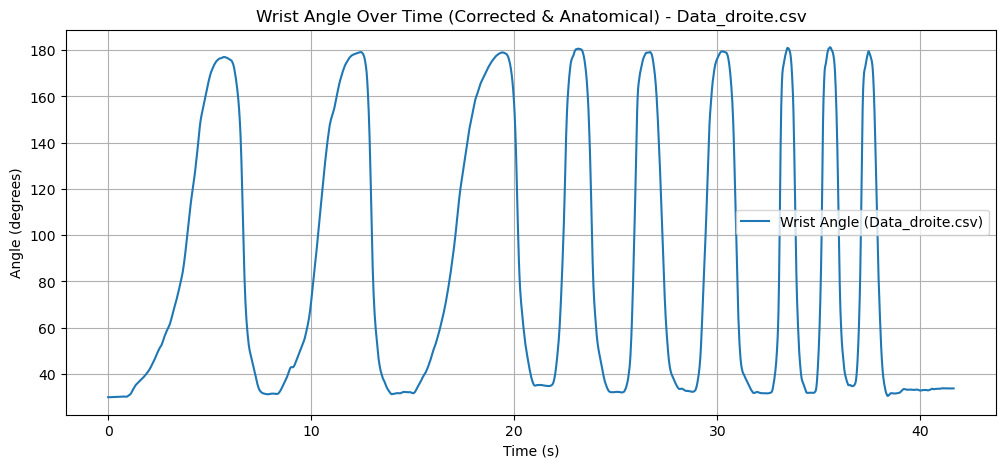

===== FILE: Data_droite.csv =====
Min angle: 29.980334670589514
Max angle: 181.26199870636566


In [29]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_droite.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_droite.csv": 30,
   
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

First 5 rows with filtered angle:
     time      angle  angle_filt
0  0.000  30.000000   30.000042
1  0.008  29.992845   29.994383
2  0.016  29.989396   29.989358
3  0.024  29.984071   29.985518
4  0.032  29.980335   29.983244


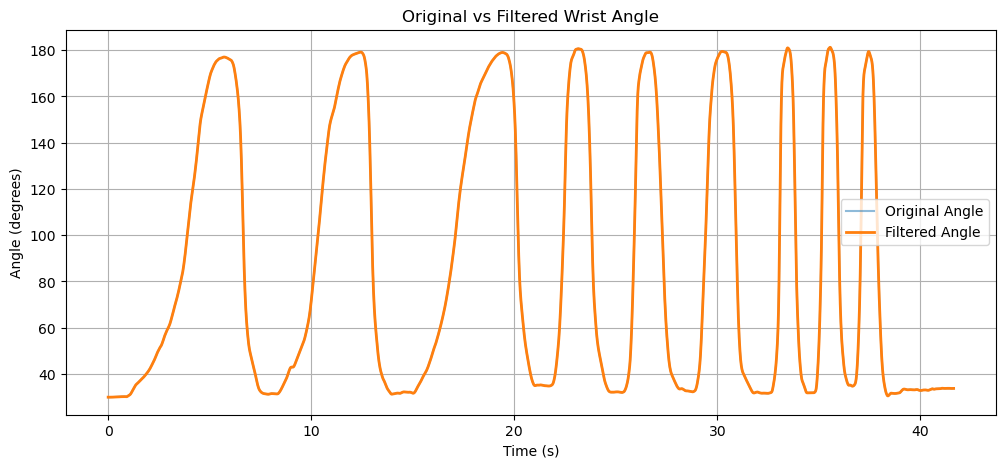

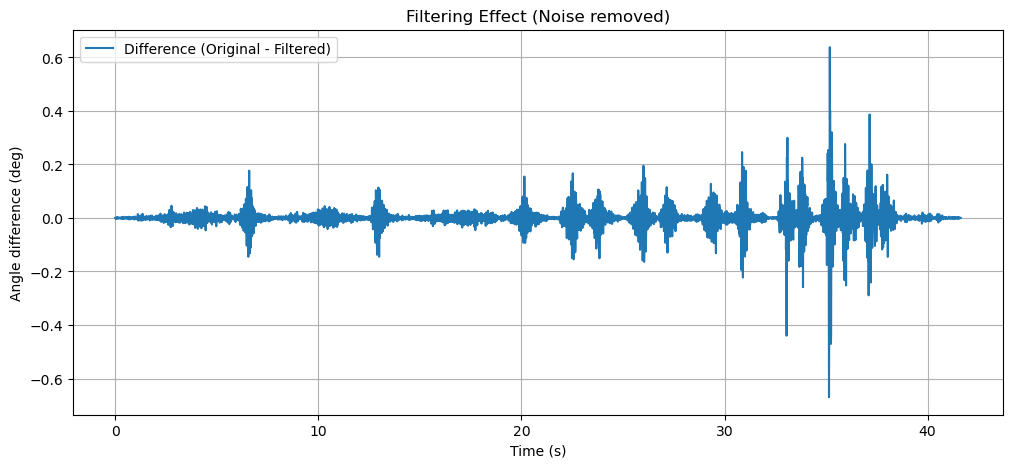

In [31]:
## STEP 3 : FILTER the data  + Chek results with plots 

from scipy.signal import butter, filtfilt

def lowpass_filter(signal, fs, cutoff=10, order=4):
    """
    Apply a Butterworth low-pass filter.

    Parameters:
        signal : array-like
        fs : sampling frequency (Hz)
        cutoff : cutoff frequency (Hz)
        order : filter order

    Returns:
        filtered_signal
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal

# ---------- APPLY FILTER TO ANGLE ----------
fs = 125  # sampling frequency

df_wrist_angles["angle_filt"] = lowpass_filter(
    df_wrist_angles["angle"],
    fs=fs,
    cutoff=10
)
# ---------- CHECK ----------
print("First 5 rows with filtered angle:\n", df_wrist_angles.head())
plt.figure(figsize=(12,5))
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle"],
    label="Original Angle",
    alpha=0.5
)
plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle_filt"],
    label="Filtered Angle",
    linewidth=2
)
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Original vs Filtered Wrist Angle")
plt.legend()
plt.grid(True)
plt.show()   

# Difference signal
df_wrist_angles["diff"] = df_wrist_angles["angle"] - df_wrist_angles["angle_filt"]

plt.figure(figsize=(12,5))

plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["diff"],
    label="Difference (Original - Filtered)"
)

plt.xlabel("Time (s)")
plt.ylabel("Angle difference (deg)")
plt.title("Filtering Effect (Noise removed)")
plt.legend()
plt.grid(True)

plt.show()

Extension peaks (max): [ 715 1555 2427 2892 3334 3780 4183 4444 4681]
Extension values: [177.015222   179.15958977 179.00851863 180.6377516  179.17330486
 179.45873258 180.97740318 181.22065221 179.40828618]
Flexion peaks (min): [   5  983 1746 3162 3597 4056 4304 4799 5000]
Flexion values: [29.98269837 31.25356795 31.30177959 32.02873294 32.30595716 31.63336577
 31.85129529 30.54386397 32.88022472]
Number of extension peaks: 9
Number of flexion peaks: 9


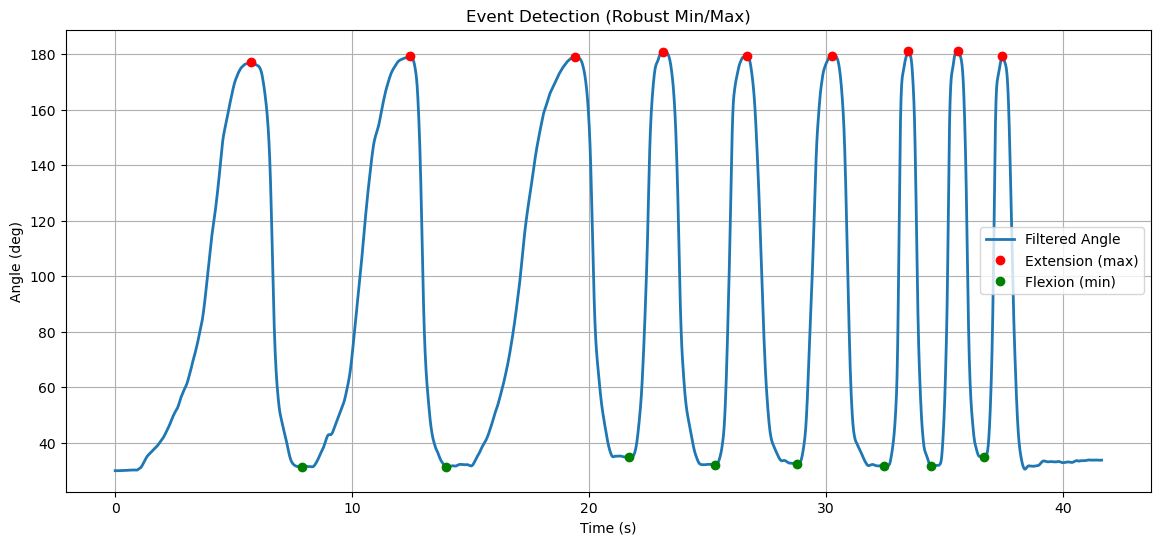

In [33]:
# STEP 4 : EVENT DETECTION from the PEAK +  CHECK RESULTS WITH PLOTS

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---------- STEP 5: EVENT DETECTION FROM FILTERED ANGLE ----------

# Use filtered angle
signal = df_wrist_angles["angle_filt"].values
time = df_wrist_angles["time"].values

# ---------- 1. DETECT EXTENSION (MAXIMA) ----------
peaks_extension, _ = find_peaks(
    signal,
    distance=200
)

# ---------- 2. DETECT FLEXION (MINIMA) ----------
peaks_flexion_all, _ = find_peaks(
    -signal,
    distance=200
)

# Get values
flexion_values = signal[peaks_flexion_all]

# Sort (lowest = strongest flexion)
sorted_indices = np.argsort(flexion_values)

# Keep 9 deepest minima
peaks_flexion = np.sort(peaks_flexion_all[sorted_indices[:9]])

# ---------- OPTIONAL FIX ----------
if signal[0] > signal[1]:
    peaks_extension = np.insert(peaks_extension, 0, 0)

# keep the 9 highest maxima
ext_values = signal[peaks_extension]
top_idx = np.argsort(ext_values)[-9:]
peaks_extension = np.sort(peaks_extension[top_idx])

# ---------- DEBUG ----------
print("Extension peaks (max):", peaks_extension)
print("Extension values:", signal[peaks_extension])

print("Flexion peaks (min):", peaks_flexion)
print("Flexion values:", signal[peaks_flexion])

print("Number of extension peaks:", len(peaks_extension))
print("Number of flexion peaks:", len(peaks_flexion))

# ---------- FORCE 1 MINIMUM BETWEEN EACH MAX ----------
peaks_flexion_fixed = []

for i in range(len(peaks_extension) - 1):
    start = peaks_extension[i]
    end = peaks_extension[i+1]

    # segment between two maxima
    segment = signal[start:end]

    if len(segment) == 0:
        continue

    # find minimum in this segment
    local_min_idx = np.argmin(segment)

    # convert to global index
    peaks_flexion_fixed.append(start + local_min_idx)

peaks_flexion_fixed = np.array(peaks_flexion_fixed)


plt.figure(figsize=(14,6))

plt.plot(time, signal, label="Filtered Angle", linewidth=2)

# Max (extension)
plt.plot(time[peaks_extension], signal[peaks_extension],
         "ro", label="Extension (max)")

# Min (flexion)
plt.plot(time[peaks_flexion_fixed], signal[peaks_flexion_fixed],
         "go", label="Flexion (min)")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Detection (Robust Min/Max)")
plt.legend()
plt.grid(True)

plt.show()

In [34]:


# Step 6 : Associate events to force

# Convert event indices to time
event_times = time[peaks_extension]

# Find corresponding force values
force_values = []

for t in event_times:
    idx_force = (df_push["time"] - t).abs().idxmin()
    force_values.append(df_push["force"].iloc[idx_force])

df_events = pd.DataFrame({
    "time": event_times,
    "angle": signal[peaks_extension],
    "force": force_values
})

print(df_events.head())

     time       angle   force
0   5.720  177.015222  0.9667
1  12.440  179.159590  0.6267
2  19.416  179.008519  0.6263
3  23.136  180.637752  0.8491
4  26.672  179.173305  0.0000


Slow Events:
      time       angle   force
0   5.720  177.015222  0.9667
1  12.440  179.159590  0.6267
2  19.416  179.008519  0.6263

Medium Events:
      time       angle   force
0  23.136  180.637752  0.8491
1  26.672  179.173305  0.0000
2  30.240  179.458733  0.5426

Fast Events:
      time       angle   force
0  33.464  180.977403  0.4994
1  35.552  181.220652  0.4000
2  37.448  179.408286  0.4551


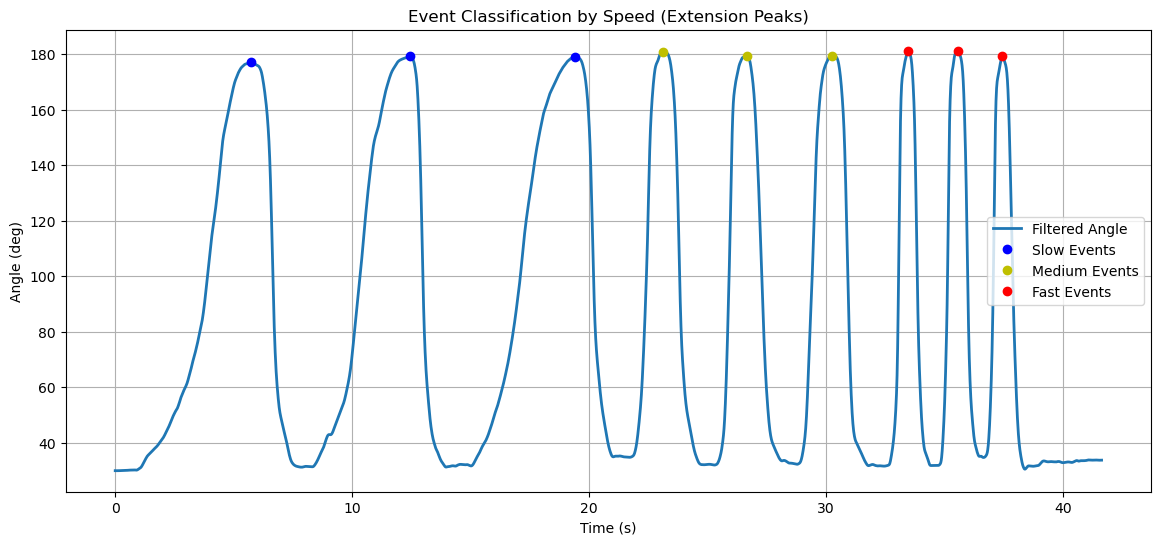

In [35]:
# ==========================================================
# STEP 7: CLASSIFY EVENTS INTO SPEED CATEGORIES
# ==========================================================

import pandas as pd

# ---------- PARAMETERS ----------
# Assume we have 9 extension peaks (already detected)
n_events_per_category = 3  # 3 slow, 3 medium, 3 fast

# Sort peaks by time to respect chronological order
sorted_extension_peaks = np.sort(peaks_extension)

# Split into 3 categories: slow, medium, fast
slow_peaks = sorted_extension_peaks[:n_events_per_category]
medium_peaks = sorted_extension_peaks[n_events_per_category:2*n_events_per_category]
fast_peaks = sorted_extension_peaks[2*n_events_per_category:3*n_events_per_category]

# ---------- ASSOCIATE ANGLE AND FORCE ----------
def get_event_data(peaks, signal, df_push, time_array):
    """
    Get angle and corresponding force for each peak.
    
    peaks : array of peak indices
    signal : filtered angle signal
    df_push : dataframe with force data (time + force)
    time_array : array of time values
    """
    event_times = time_array[peaks]
    force_values = []
    for t in event_times:
        idx_force = (df_push["time"] - t).abs().idxmin()  # find nearest time in force
        force_values.append(df_push["force"].iloc[idx_force])
    
    df_events = pd.DataFrame({
        "time": event_times,
        "angle": signal[peaks],
        "force": force_values
    })
    
    return df_events

# ---------- CREATE DATAFRAMES FOR EACH CATEGORY ----------
df_slow = get_event_data(slow_peaks, signal, df_push, time)
df_medium = get_event_data(medium_peaks, signal, df_push, time)
df_fast = get_event_data(fast_peaks, signal, df_push, time)

# ---------- PRINT RESULTS ----------
print("Slow Events:\n", df_slow)
print("\nMedium Events:\n", df_medium)
print("\nFast Events:\n", df_fast)

# ---------- OPTIONAL: PLOT EVENTS WITH COLORS ----------
plt.figure(figsize=(14,6))
plt.plot(time, signal, label="Filtered Angle", linewidth=2)
plt.plot(time[slow_peaks], signal[slow_peaks], "bo", label="Slow Events")
plt.plot(time[medium_peaks], signal[medium_peaks], "yo", label="Medium Events")
plt.plot(time[fast_peaks], signal[fast_peaks], "ro", label="Fast Events")
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Classification by Speed (Extension Peaks)")
plt.legend()
plt.grid(True)
plt.show()

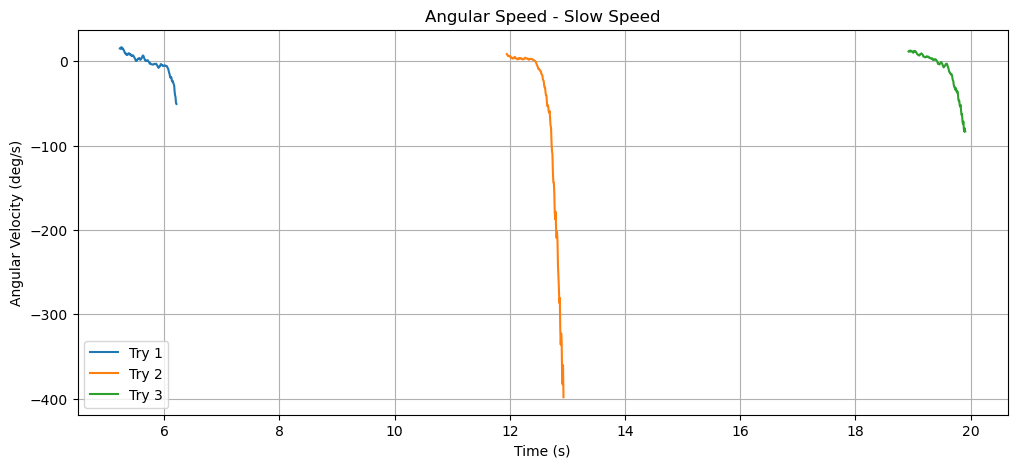

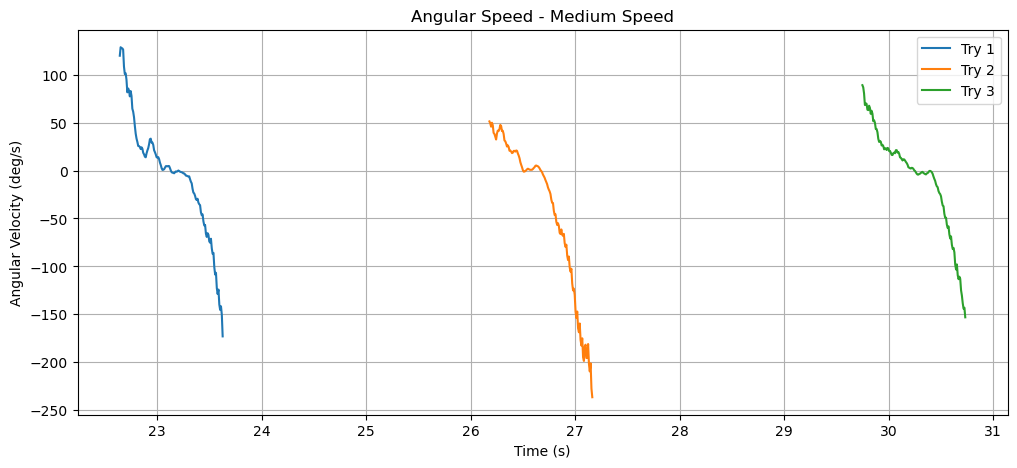

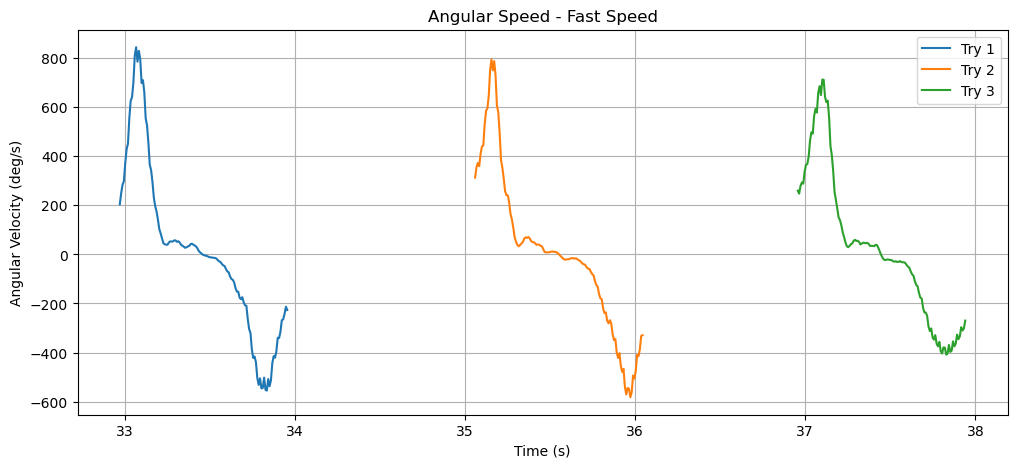

In [36]:
# ==========================================================
# STEP 8: COMPUTE ANGULAR VELOCITY AND PLOT PER CATEGORY
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------- FUNCTION TO COMPUTE ANGULAR VELOCITY ----------
def compute_angular_velocity(df_angles):
    """
    Compute angular velocity (deg/s) from a dataframe with time and angle.

    df_angles: dataframe with columns "time" and "angle"

    Returns:
        time_mid: array of times for velocity points
        vel: array of angular velocities
    """
    time = df_angles["time"].values
    angle = df_angles["angle"].values

    # Compute derivative (angular velocity) using np.diff
    vel = np.diff(angle) / np.diff(time)

    # Midpoint times for derivative points
    time_mid = time[:-1] + np.diff(time)/2

    return time_mid, vel

# ---------- FUNCTION TO EXTRACT ANGLE SEGMENTS AROUND EVENTS ----------
def extract_event_segments(peaks, df_angles, window=0.5):
    """
    Extract small segments of the angle signal around each peak.
    
    peaks: array of indices of extension peaks
    df_angles: full angle dataframe
    window: time before/after peak to include (s)
    """
    segments = []
    for peak in peaks:
        t_peak = df_angles["time"].iloc[peak]
        # Select segment ±window around peak
        seg = df_angles[(df_angles["time"] >= t_peak - window) &
                        (df_angles["time"] <= t_peak + window)].copy()
        segments.append(seg)
    return segments

# ---------- PLOT FUNCTION ----------
def plot_angular_velocity_category(df_angles, peaks, category_name):
    """
    Plot angular velocity for each of the 3 events in a category.
    """
    segments = extract_event_segments(peaks, df_angles, window=0.5)

    plt.figure(figsize=(12,5))

    for i, seg in enumerate(segments):
        time_mid, vel = compute_angular_velocity(seg)
        plt.plot(time_mid, vel, label=f"Try {i+1}")

    plt.xlabel("Time (s)")
    plt.ylabel("Angular Velocity (deg/s)")
    plt.title(f"Angular Speed - {category_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


# ---------- APPLY TO EACH CATEGORY ----------

# Slow events
plot_angular_velocity_category(df_wrist_angles, slow_peaks, "Slow Speed")

# Medium events
plot_angular_velocity_category(df_wrist_angles, medium_peaks, "Medium Speed")

# Fast events
plot_angular_velocity_category(df_wrist_angles, fast_peaks, "Fast Speed")

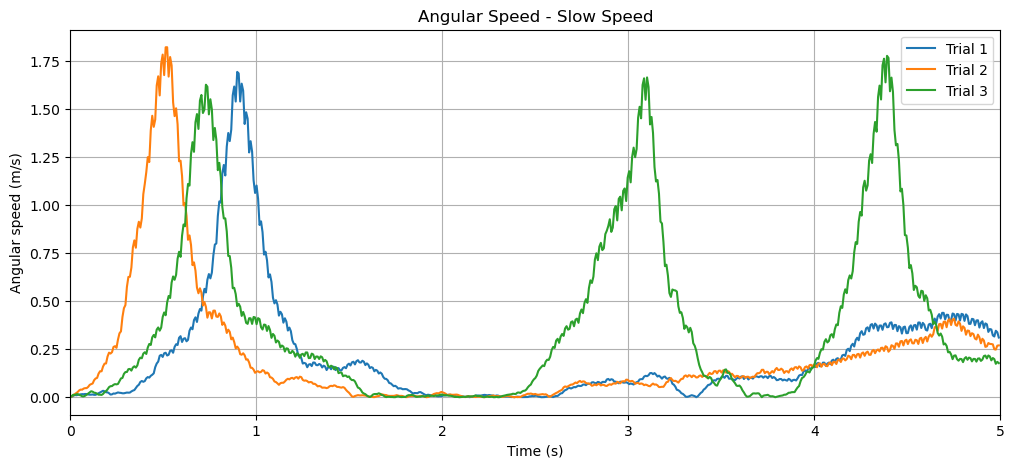

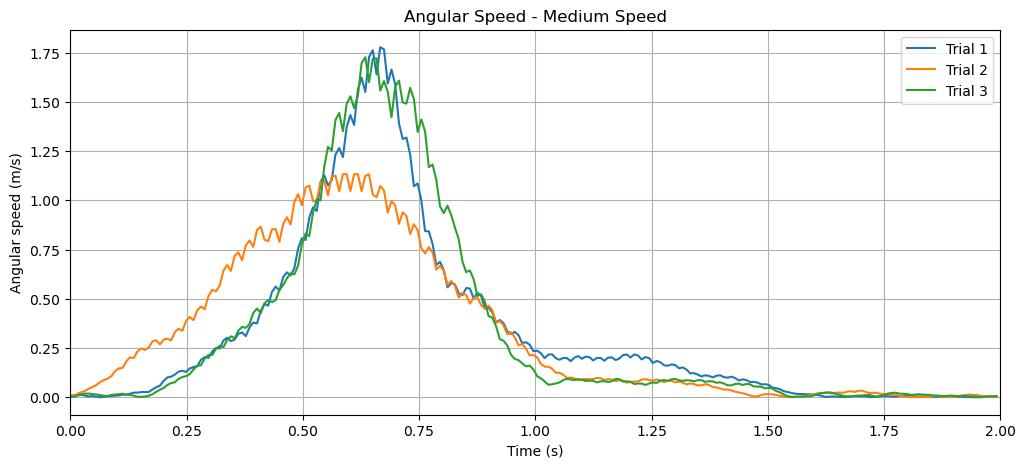

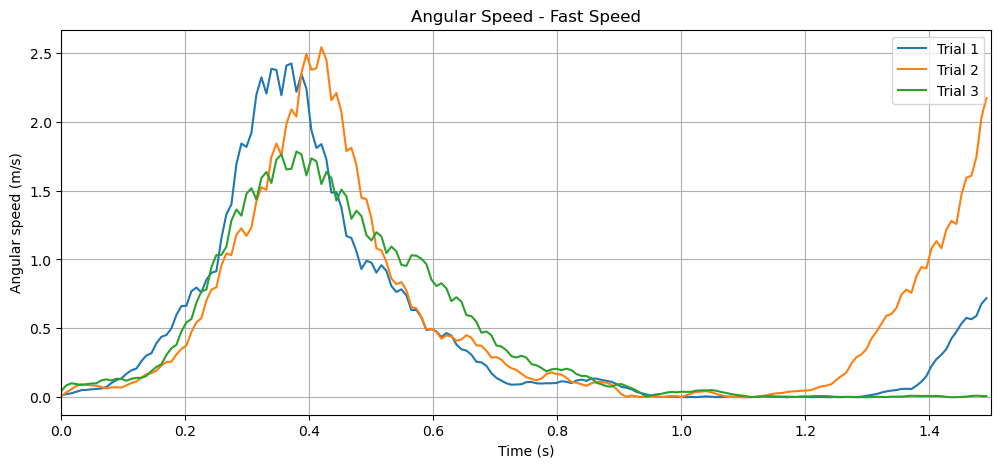

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
r = 0.25  # radius from joint center to wrist (m)
window_dict = {"Slow": 5.0, "Medium": 2.0, "Fast": 1.5}  # x-axis windows

# ---------- FUNCTION: ANGULAR VELOCITY ----------
def compute_angular_velocity_m_per_s(df_angles, r):
    """
    Convert angles (deg) to linear speed (m/s)
    using absolute value to avoid negative speeds.
    """
    time = df_angles["time"].values
    angle = df_angles["angle"].values
    angle_rad = np.radians(angle)
    vel_rad_s = np.diff(angle_rad) / np.diff(time)
    vel_m_s = np.abs(vel_rad_s) * r  # <-- take absolute value
    time_mid = time[:-1] + np.diff(time)/2
    return time_mid, vel_m_s

# ---------- FUNCTION: EXTRACT SYNCHRONIZED SEGMENTS ----------
def extract_synchronized_segments(peaks, df_angles, total_window):
    """
    Extract a segment of fixed number of points after each peak.
    Ensures segments are not empty.
    """
    segments = []
    dt = np.mean(np.diff(df_angles["time"]))  # sampling interval
    n_points = int(total_window / dt)         # number of points to include

    for peak in peaks:
        start_idx = peak
        end_idx = min(peak + n_points, len(df_angles))
        seg = df_angles.iloc[start_idx:end_idx].copy()
        seg["time_sync"] = np.linspace(0, total_window, len(seg))  # rescale x-axis to window
        segments.append(seg)
    return segments

# ---------- FUNCTION: PLOT SYNCHRONIZED VELOCITY ----------
def plot_synchronized_velocity(df_angles, peaks, category_name, window, r):
    """
    Plot multiple trials of the same speed, synchronized in time.
    """
    segments = extract_synchronized_segments(peaks, df_angles, window)

    plt.figure(figsize=(12,5))

    for i, seg in enumerate(segments):
        if len(seg) < 2:
            continue  # skip empty segments
        time_mid, vel = compute_angular_velocity_m_per_s(seg, r)
        plt.plot(seg["time_sync"][:-1], vel, label=f"Trial {i+1}")

    plt.xlabel("Time (s)")
    plt.ylabel("Angular speed (m/s)")
    plt.title(f"Angular Speed - {category_name}")
    plt.grid(True)
    plt.xlim(0, window)
    plt.legend()
    plt.show()

# ---------- EXAMPLES ----------
plot_synchronized_velocity(df_wrist_angles, slow_peaks, "Slow Speed", window_dict["Slow"], r)
plot_synchronized_velocity(df_wrist_angles, medium_peaks, "Medium Speed", window_dict["Medium"], r)
plot_synchronized_velocity(df_wrist_angles, fast_peaks, "Fast Speed", window_dict["Fast"], r)

In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_GG.csv"]  # Example single file

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }



===== FILE: Data_Gh_D.csv =====
K-Push:
     time    force
0  0.000  1.11355
1  0.002  1.13235
2  0.004  1.11425
3  0.006  1.07785
4  0.008  1.08425

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000 -0.578369 -0.184753  0.241943  0.756775
1  0.008 -0.578325 -0.184728  0.241920  0.756858
2  0.016 -0.578228 -0.184696  0.241856  0.756973
3  0.024 -0.578136 -0.184726  0.241765  0.757064
4  0.032 -0.578050 -0.184789  0.241675  0.757132

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.405029  0.515686 -0.699524  0.283813
1  0.008 -0.405223  0.515639 -0.699451  0.283943
2  0.016 -0.405559  0.515487 -0.699269  0.284188
3  0.024 -0.405803  0.515364 -0.699146  0.284370
4  0.032 -0.405894  0.515302 -0.699115  0.284431

Baseline wrist: [-0.385, 0.52, -0.705, 0.289]
Baseline shoulder: [-0.576, -0.184, 0.255, 0.755]

Shapes: (32800, 2) (8196, 5) (8196, 5)


In [ ]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_GG.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_GG.csv":30,

}

# Store results
angles_results = {30}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

KeyError: 'Data_GG.csv'